<a href="https://colab.research.google.com/github/edestanc-art/DECODING-NYC-TAXI-TRIPS-ANOMALY-DETECTION-AND-FARE-BEHAVIOR-ANALYSIS/blob/main/NYC_Yellow_Taxi_Trip_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import datetime
from matplotlib import pyplot as plt

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving 2017 Yellow Taxi Trip Data (1).csv to 2017 Yellow Taxi Trip Data (1).csv


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os

os.listdir()

['.config', 'drive', '2017 Yellow Taxi Trip Data (1).csv', 'sample_data']

In [ ]:
import pandas as pd

df = pd.read_csv("2017 Yellow Taxi Trip Data (1).csv")
df.head()

,Unnamed: 0,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
0,24870114,2,03/25/2017 8:55:43 AM,03/25/2017 9:09:47 AM,6,3.34,1,N,100,231,1,13.0,0.0,0.5,2.76,0.0,0.3,16.56
1,35634249,1,04/11/2017 2:53:28 PM,04/11/2017 3:19:58 PM,1,1.80,1,N,186,43,1,16.0,0.0,0.5,4.00,0.0,0.3,20.80
2,106203690,1,12/15/2017 7:26:56 AM,12/15/2017 7:34:08 AM,1,1.00,1,N,262,236,1,6.5,0.0,0.5,1.45,0.0,0.3,8.75
3,38942136,2,05/07/2017 1:17:59 PM,05/07/2017 1:48:14 PM,1,3.70,1,N,188,97,1,20.5,0.0,0.5,6.39,0.0,0.3,27.69
4,30841670,2,04/15/2017 11:32:20 PM,04/15/2017 11:49:03 PM,1,4.37,1,N,4,112,2,16.5,0.5,0.5,0.00,0.0,0.3,17.80


In [ ]:
#print 10 top rows
df.head(10)

,Unnamed: 0,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
0,24870114,2,03/25/2017 8:55:43 AM,03/25/2017 9:09:47 AM,6,3.34,1,N,100,231,1,13.0,0.0,0.5,2.76,0.0,0.3,16.56
1,35634249,1,04/11/2017 2:53:28 PM,04/11/2017 3:19:58 PM,1,1.80,1,N,186,43,1,16.0,0.0,0.5,4.00,0.0,0.3,20.80
2,106203690,1,12/15/2017 7:26:56 AM,12/15/2017 7:34:08 AM,1,1.00,1,N,262,236,1,6.5,0.0,0.5,1.45,0.0,0.3,8.75
3,38942136,2,05/07/2017 1:17:59 PM,05/07/2017 1:48:14 PM,1,3.70,1,N,188,97,1,20.5,0.0,0.5,6.39,0.0,0.3,27.69
4,30841670,2,04/15/2017 11:32:20 PM,04/15/2017 11:49:03 PM,1,4.37,1,N,4,112,2,16.5,0.5,0.5,0.00,0.0,0.3,17.80
5,23345809,2,03/25/2017 8:34:11 PM,03/25/2017 8:42:11 PM,6,2.30,1,N,161,236,1,9.0,0.5,0.5,2.06,0.0,0.3,12.36
6,37660487,2,05/03/2017 7:04:09 PM,05/03/2017 8:03:47 PM,1,12.83,1,N,79,241,1,47.5,1.0,0.5,9.86,0.0,0.3,59.16
7,69059411,2,08/15/2017 5:41:06 PM,08/15/2017 6:03:05 PM,1,2.98,1,N,237,114,1,16.0,1.0,0.5,1.78,0.0,0.3,19.58
8,8433159,2,02/04/2017 4:17:07 PM,02/04/2017 4:29:14 PM,1,1.20,1,N,234,249,2,9.0,0.0,0.5,0.00,0.0,0.3,9.80
9,95294817,1,11/10/2017 3:20:29 PM,11/10/2017 3:40:55 PM,1,1.60,1,N,239,237,1,13.0,0.0,0.5,2.75,0.0,0.3,16.55


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22699 entries, 0 to 22698
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Unnamed: 0             22699 non-null  int64  
 1   VendorID               22699 non-null  int64  
 2   tpep_pickup_datetime   22699 non-null  object 
 3   tpep_dropoff_datetime  22699 non-null  object 
 4   passenger_count        22699 non-null  int64  
 5   trip_distance          22699 non-null  float64
 6   RatecodeID             22699 non-null  int64  
 7   store_and_fwd_flag     22699 non-null  object 
 8   PULocationID           22699 non-null  int64  
 9   DOLocationID           22699 non-null  int64  
 10  payment_type           22699 non-null  int64  
 11  fare_amount            22699 non-null  float64
 12  extra                  22699 non-null  float64
 13  mta_tax                22699 non-null  float64
 14  tip_amount             22699 non-null  float64
 15  to

In [ ]:
cols = [
    'passenger_count',
    'trip_distance',
    'fare_amount',
    'tip_amount',
    'tolls_amount',
    'total_amount'
]

In [ ]:
df[cols].describe()

,passenger_count,trip_distance,fare_amount,tip_amount,tolls_amount,total_amount
count,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000
mean,1.642319,2.913313,13.026629,1.835781,0.312542,16.310502
std,1.285231,3.653171,13.243791,2.800626,1.399212,16.097295
min,0.000000,0.000000,-120.000000,0.000000,0.000000,-120.300000
25%,1.000000,0.990000,6.500000,0.000000,0.000000,8.750000
50%,1.000000,1.610000,9.500000,1.350000,0.000000,11.800000
75%,2.000000,3.060000,14.500000,2.450000,0.000000,17.800000
max,6.000000,33.960000,999.990000,200.000000,19.100000,1200.290000


In [ ]:
import matplotlib.pyplot as plt

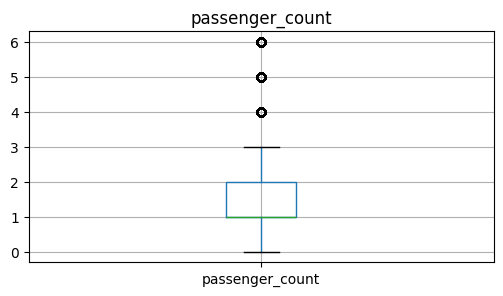

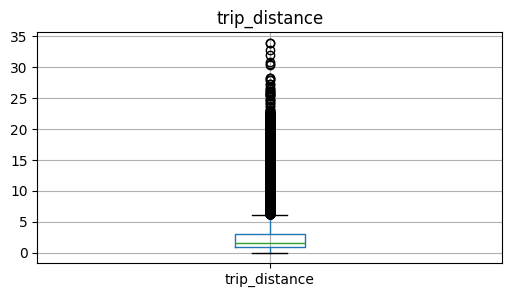

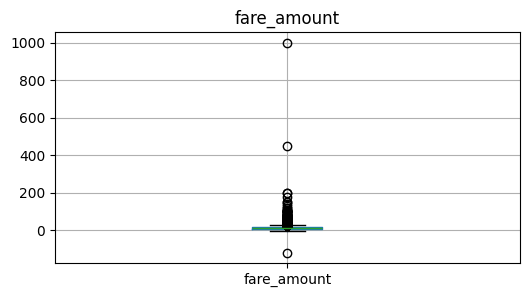

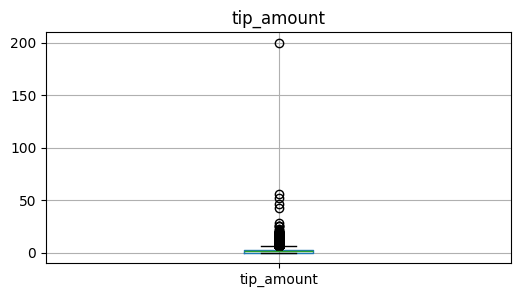

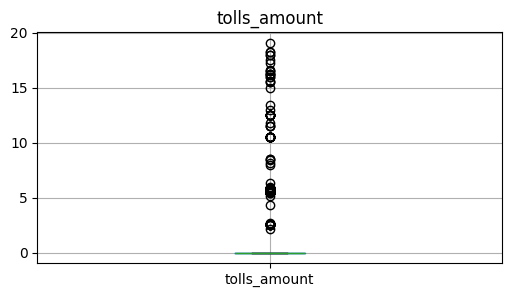

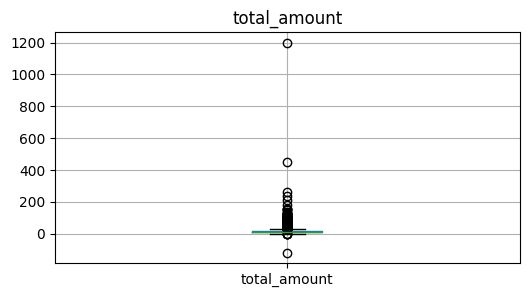

In [ ]:
for col in cols:
 plt.figure(figsize=(6,3))
 df.boxplot(column=col)
 plt.title(col)
 plt.show()

In [ ]:
cols = [
    'passenger_count',
    'trip_distance',
    'fare_amount',
    'tip_amount',
    'tolls_amount',
    'total_amount'
]

for col in cols:
    print(f"\n{col}")
    print(f"Mean   : {df[col].mean():.2f}")
    print(f"Median : {df[col].median():.2f}")


passenger_count
Mean   : 1.64
Median : 1.00

trip_distance
Mean   : 2.91
Median : 1.61

fare_amount
Mean   : 13.03
Median : 9.50

tip_amount
Mean   : 1.84
Median : 1.35

tolls_amount
Mean   : 0.31
Median : 0.00

total_amount
Mean   : 16.31
Median : 11.80


In [ ]:
summary = pd.DataFrame({
    'Mean': df[cols].mean(),
    'Median': df[cols].median()
})

summary

,Mean,Median
passenger_count,1.642319,1.00
trip_distance,2.913313,1.61
fare_amount,13.026629,9.50
tip_amount,1.835781,1.35
tolls_amount,0.312542,0.00
total_amount,16.310502,11.80


In [ ]:
"""Since every mean is greater than its median, the distributions are likely positively skewed (right-skThis means most rides are short.
Most fares are moderate.
A small number of airport rides or long-distance trips are very expensive."""

'Since every mean is greater than its median, the distributions are likely positively skewed (right-skThis means most rides are short.\nMost fares are moderate.\nA small number of airport rides or long-distance trips are very expensive.'

In [ ]:
cols = [
    'passenger_count',
    'trip_distance',
    'fare_amount',
    'tip_amount',
    'tolls_amount',
    'total_amount'
]

df[cols].skew()

,0
passenger_count,2.172872
trip_distance,2.994913
fare_amount,21.663101
tip_amount,18.188305
tolls_amount,5.082727
total_amount,20.389403


In [ ]:
#This suggests there are some trips with:
#unusually large fares
#unusually large tips
#unusually large total amounts
#compared to the majority of trips."""

In [ ]:
#The record causing this
df.nlargest(10, 'fare_amount')[
    ['trip_distance',
     'fare_amount',
     'tip_amount',
     'total_amount']
]

,trip_distance,fare_amount,tip_amount,total_amount
8476,2.60,999.99,200.00,1200.29
20312,0.00,450.00,0.00,450.30
13861,33.92,200.01,51.64,258.21
15474,0.00,200.00,11.00,211.80
12511,0.00,175.00,46.69,233.74
3582,7.30,152.00,0.00,152.30
9280,33.96,150.00,0.00,150.30
16379,25.50,140.00,0.00,157.06
10291,31.95,131.00,0.00,131.80
1928,12.50,120.00,5.00,137.80


In [ ]:
df.nlargest(10, 'trip_distance')[
    ['trip_distance',
     'fare_amount',
     'total_amount']
]

,trip_distance,fare_amount,total_amount
9280,33.96,150.00,150.30
13861,33.92,200.01,258.21
6064,32.72,107.00,179.06
10291,31.95,131.00,131.80
29,30.83,80.00,111.38
18130,30.50,90.50,119.31
5792,30.33,52.00,73.20
15350,28.23,52.00,62.96
10302,28.20,52.00,70.27
2592,27.97,52.00,63.06


In [ ]:
#Quantiles and InterQuantiles
Q1 = df['trip_distance'].quantile(0.25)
Q3 = df['trip_distance'].quantile(0.75)

IQR = Q3 - Q1

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)

Q1: 0.99
Q3: 3.06
IQR: 2.0700000000000003


In [ ]:
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print("Lower Bound:", lower)
print("Upper Bound:", upper)

Lower Bound: -2.115
Upper Bound: 6.165000000000001


In [ ]:
outliers = df[
    (df['trip_distance'] < lower) |
    (df['trip_distance'] > upper)
]

print("Number of outliers:", len(outliers))

Number of outliers: 2527


In [ ]:
#All trips with zero distances
df[df['trip_distance'] == 0][
    ['trip_distance',
     'fare_amount',
     'tip_amount',
     'total_amount']
].head(20)

,trip_distance,fare_amount,tip_amount,total_amount
128,0.0,20.0,0.00,20.30
246,0.0,2.5,0.00,3.80
291,0.0,2.5,0.00,4.30
319,0.0,2.5,0.00,3.80
424,0.0,2.5,6.70,10.00
470,0.0,34.0,6.96,41.76
472,0.0,9.5,0.00,11.30
572,0.0,52.0,11.71,70.27
647,0.0,2.5,3.00,6.80
795,0.0,8.0,0.00,8.80


In [ ]:
#Count
(df['trip_distance'] == 0).sum()

np.int64(148)

In [ ]:
#Fare Amount less than  zero
df[df['fare_amount'] < 0][
    ['trip_distance',
     'fare_amount',
     'tip_amount',
     'total_amount']
]

,trip_distance,fare_amount,tip_amount,total_amount
314,0.12,-2.5,0.0,-3.8
1646,0.04,-2.5,0.0,-3.3
4423,0.06,-3.0,0.0,-4.3
5448,0.25,-3.5,0.0,-4.3
5758,0.02,-2.5,0.0,-3.8
8204,0.41,-3.5,0.0,-4.8
10281,0.00,-2.5,0.0,-4.3
11204,0.64,-4.5,0.0,-5.3
12944,0.17,-120.0,0.0,-120.3
14714,0.40,-4.0,0.0,-5.3


In [ ]:
#Trip Distance zero
df[df['trip_distance'] == 0][
    ['fare_amount',
     'tip_amount',
     'total_amount']
].describe()

,fare_amount,tip_amount,total_amount
count,148.000000,148.000000,148.000000
mean,23.130743,2.658378,27.537095
std,47.338249,6.034297,51.098598
min,-2.500000,0.000000,-4.300000
25%,2.500000,0.000000,3.800000
50%,3.000000,0.000000,6.710000
75%,30.000000,2.130000,32.437500
max,450.000000,46.690000,450.300000


In [ ]:
#Fare Distribution
df['fare_amount'].describe(percentiles=[0.90, 0.95, 0.99])

,fare_amount
count,22699.000000
mean,13.026629
std,13.243791
min,-120.000000
50%,9.500000
90%,25.500000
95%,36.000000
99%,52.000000
max,999.990000


In [ ]:
df[df['trip_distance'] == 0][
    ['trip_distance',
     'fare_amount',
     'tip_amount',
     'total_amount']
].head(20)

,trip_distance,fare_amount,tip_amount,total_amount
128,0.0,20.0,0.00,20.30
246,0.0,2.5,0.00,3.80
291,0.0,2.5,0.00,4.30
319,0.0,2.5,0.00,3.80
424,0.0,2.5,6.70,10.00
470,0.0,34.0,6.96,41.76
472,0.0,9.5,0.00,11.30
572,0.0,52.0,11.71,70.27
647,0.0,2.5,3.00,6.80
795,0.0,8.0,0.00,8.80


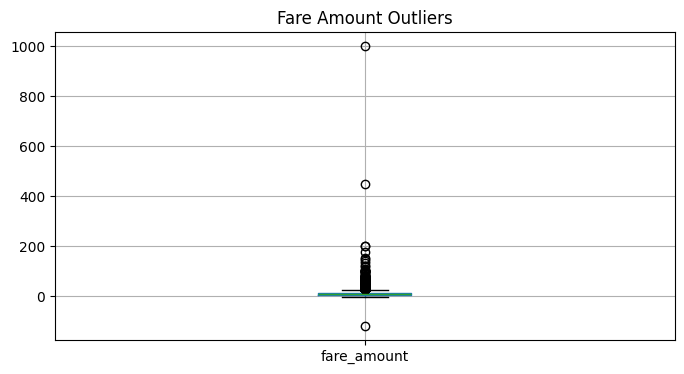

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
df.boxplot(column='fare_amount')
plt.title('Fare Amount Outliers')
plt.show()

In [ ]:
#Investigate Negative fares
df[df['fare_amount'] < 0]

,Unnamed: 0,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
314,105454287,2,12/13/2017 2:02:39 AM,12/13/2017 2:03:08 AM,6,0.12,1,N,161,161,3,-2.5,-0.5,-0.5,0.0,0.0,-0.3,-3.8
1646,57337183,2,07/05/2017 11:02:23 AM,07/05/2017 11:03:00 AM,1,0.04,1,N,79,79,3,-2.5,0.0,-0.5,0.0,0.0,-0.3,-3.3
4423,97329905,2,11/16/2017 8:13:30 PM,11/16/2017 8:14:50 PM,2,0.06,1,N,237,237,4,-3.0,-0.5,-0.5,0.0,0.0,-0.3,-4.3
5448,28459983,2,04/06/2017 12:50:26 PM,04/06/2017 12:52:39 PM,1,0.25,1,N,90,68,3,-3.5,0.0,-0.5,0.0,0.0,-0.3,-4.3
5758,833948,2,01/03/2017 8:15:23 PM,01/03/2017 8:15:39 PM,1,0.02,1,N,170,170,3,-2.5,-0.5,-0.5,0.0,0.0,-0.3,-3.8
8204,91187947,2,10/28/2017 8:39:36 PM,10/28/2017 8:41:59 PM,1,0.41,1,N,236,237,3,-3.5,-0.5,-0.5,0.0,0.0,-0.3,-4.8
10281,55302347,2,06/05/2017 5:34:25 PM,06/05/2017 5:36:29 PM,2,0.00,1,N,238,238,4,-2.5,-1.0,-0.5,0.0,0.0,-0.3,-4.3
11204,58395501,2,07/09/2017 7:20:59 AM,07/09/2017 7:23:50 AM,1,0.64,1,N,50,48,3,-4.5,0.0,-0.5,0.0,0.0,-0.3,-5.3
12944,29059760,2,04/08/2017 12:00:16 AM,04/08/2017 11:15:57 PM,1,0.17,5,N,138,138,4,-120.0,0.0,0.0,0.0,0.0,-0.3,-120.3
14714,109276092,2,12/24/2017 10:37:58 PM,12/24/2017 10:41:08 PM,5,0.40,1,N,164,161,4,-4.0,-0.5,-0.5,0.0,0.0,-0.3,-5.3


In [ ]:
#The shape of negative fares
neg_fares = df[df["fare_amount"] < 0]
neg_fares.shape

(14, 18)

In [ ]:
#the proportion of negative fares
len(neg_fares) / len(df) * 100

0.061676725846953606

In [ ]:
#Approximately 6.17% of trips contained negative fare values, indicating the presence of data quality issues within the dataset. Since taxi fares are expected to be non-negative under normal operating conditions, these records likely represent data entry errors, fare adjustments, refunds, or system anomalies. Their presence can distort statistical measures such as the mean fare and should be investigated or removed prior to downstream analysis.